<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day32_Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split,
                                     cross_val_score,
                                     GridSearchCV,
                                     RandomizedSearchCV,
                                     StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier,  GradientBoostingClassifier
from sklearn.svm import SVC
from scipy.stats import uniform, randint, loguniform

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Install Optuna
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 21.8 MB/s eta 0:00:00


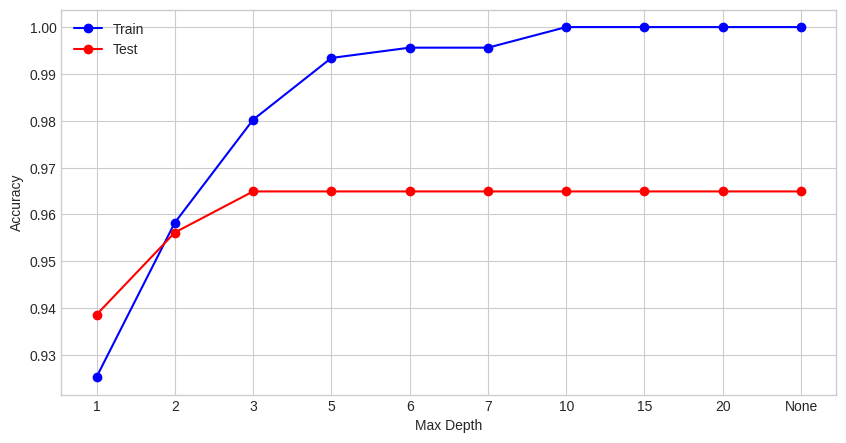

Best depth: 3


In [5]:
cancer = load_breast_cancer()
x, y = cancer.data, cancer.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

depths = [1, 2, 3, 5, 6, 7, 10, 15, 20, None]
train_scores = []
test_scores = []


for depth in depths:
  rf = RandomForestClassifier(n_estimators=50, max_depth=depth, random_state=42)
  rf.fit(x_train, y_train)
  train_scores.append(rf.score(x_train, y_train))
  test_scores.append(rf.score(x_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(len(depths)), train_scores, 'b-o', label='Train')
plt.plot(range(len(depths)), test_scores, 'r-o', label='Test')
plt.xticks(range(len(depths)), [str(d) for d in depths])
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print(f"Best depth: {depths[np.argmax(test_scores)]}")

In [7]:
cancer = load_breast_cancer()
x = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

print(f"X shape: {x.shape}")
print(f"Y shape: {y.shape}")
print(f"Classes: {cancer.target_names}")
print(f"Class balance: {y.mean():.1%} benign")

X shape: (569, 30)
Y shape: (569,)
Classes: ['malignant' 'benign']
Class balance: 62.7% benign


In [9]:
#Scaling features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(x_train)}, Test: {len(x_test)}")

Train: 455, Test: 114


Baseline

In [12]:
rf_baseline =  RandomForestClassifier(random_state=42)
rf_baseline.fit(x_train, y_train)

baseline_score = rf_baseline.score(x_test, y_test)
print(f"Baseline Random Forest")
print(f"test Accuracy: {baseline_score:.4f}")

Baseline Random Forest
test Accuracy: 0.9561


GridSearchCV (Exhaustive)

In [13]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, 200],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total combinations: {total_combinations}")
print(f"With 5-fold CV: {total_combinations * 5} fits")

Total combinations: 108
With 5-fold CV: 540 fits


In [15]:
start_time = time.time()

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)
grid_time = time.time() - start_time

print(f"Best parameters: {grid_search.best_params_}")
print(f"Time taken: {grid_time:.2f}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
print(f"Test Score: {grid_search.score(x_test, y_test):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Time taken: 219.05
Best CV Score: 0.9604
Test Score: 0.9561


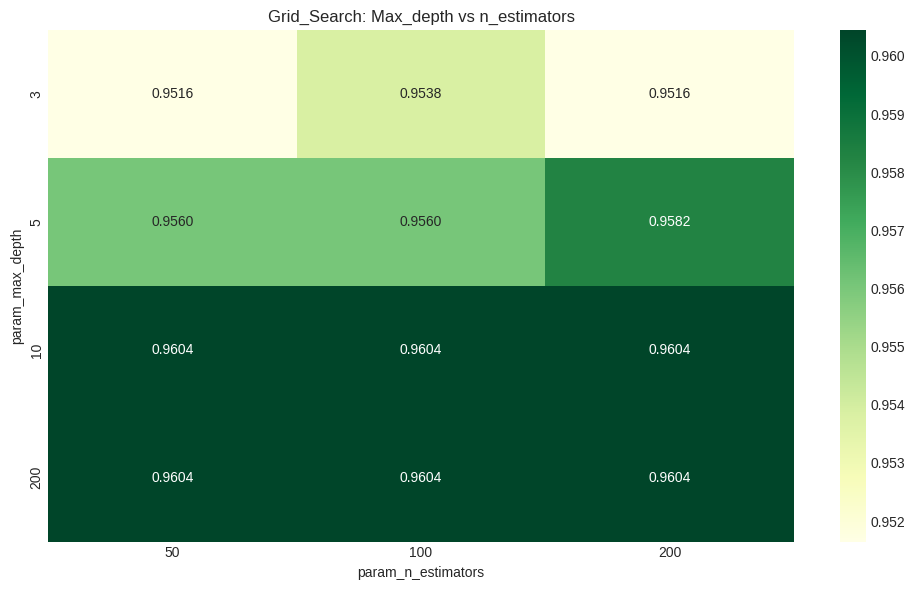

In [17]:
#Visualize the gridsearch results
results_df = pd.DataFrame(grid_search.cv_results_)

pivot =  results_df.pivot_table(
    index='param_max_depth',
    columns='param_n_estimators',
    values='mean_test_score',
    aggfunc='max'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn')
plt.title('Grid_Search: Max_depth vs n_estimators')
plt.tight_layout()
plt.show()

RandomizedSearchCV (Efficient)

In [18]:
param_distributions = {
    'n_estimators': randint(50, 100),
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

print("Running RandomizedSearchCV. . .")
start_time = time.time()

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions,
    n_iter=50,
    cv = 5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(x_train, y_train)
random_time = time.time() - start_time

print(f"Best parameters: {random_search.best_params_}")
print(f"Time taken: {random_time:.2f}")
print(f"Best CV Score: {random_search.best_score_:.4f}")
print(f"Test Score: {random_search.score(x_test, y_test):.4f}")

Running RandomizedSearchCV. . .
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 3, 'n_estimators': 70}
Time taken: 71.14
Best CV Score: 0.9560
Test Score: 0.9474


Optuna (Bayesian Optimization)

In [23]:
# optuna: smart search using past results
def objective(trial):
  """Optuna objective function for random forest."""
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 300),
      'max_depth': trial.suggest_int('max_depth', 3, 20),
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
      'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
      'random_state': 42
  }

  model = RandomForestClassifier(**params)
  scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')

  return scores.mean()

print("Running Optuna. . . ")
start_time = time.time()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

optuna_time = time.time() - start_time

print(f"Best parameters: {study.best_params}")
print(f"Time taken: {optuna_time:.2f}")
print(f"Best CV Score: {study.best_value:.4f}")

Running Optuna. . . 


  0%|          | 0/50 [00:00<?, ?it/s]

Best parameters: {'n_estimators': 173, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Time taken: 341.35
Best CV Score: 0.9582


In [25]:
#Test Optuna's best model
best_rf_optuna = RandomForestClassifier(**study.best_params, random_state=42)
best_rf_optuna.fit(x_train, y_train)
optuna_test_score = best_rf_optuna.score(x_test, y_test)

print(f"Optuna test score: {optuna_test_score:.4f}")

Optuna test score: 0.9561


/tmp/ipykernel_968/1729227918.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-o" (-> linestyle='-'). The keyword argument will take precedence.
  axes[0].plot(trials_df['number'], trials_df['value'], 'b-o', linestyle='--', label=f"Best: {study.best_value:.4f}")


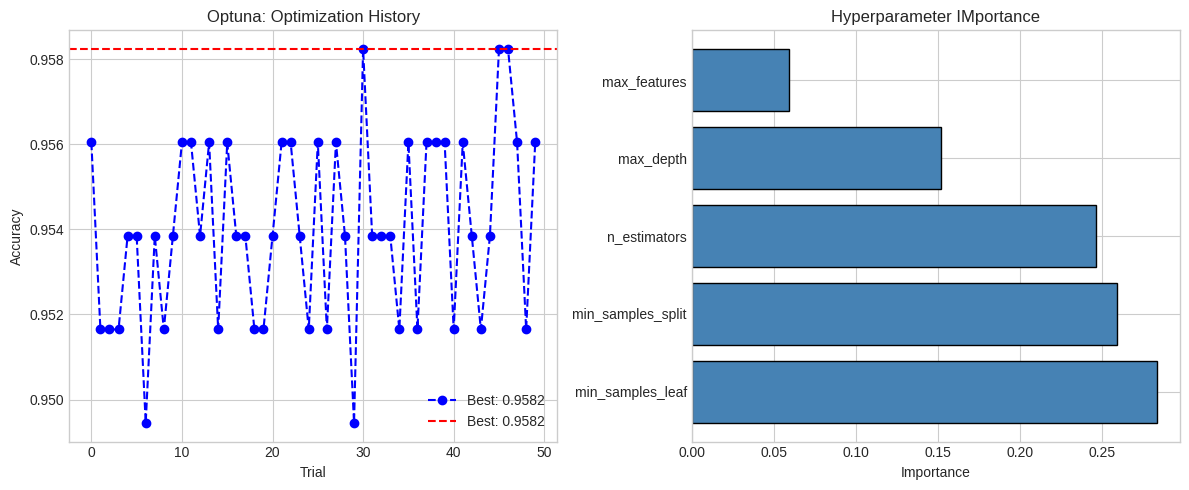

In [27]:
#Optuna's visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 'b-o', linestyle='--', label=f"Best: {study.best_value:.4f}")
axes[0].axhline(y=study.best_value, color='red', linestyle='--', label=f"Best: {study.best_value:.4f}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Accuracy")
axes[0].set_title('Optuna: Optimization History')
axes[0].legend()

#Parameter Importance
importance = optuna.importance.get_param_importances(study)
params = list(importance.keys())
values = list(importance.values())

axes[1].barh(params, values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter IMportance')

plt.tight_layout()
plt.show()

Comparing all methods

In [29]:
comparison =  {
    'Method': ['Baseline', 'GridSearchCV', 'RandomizedSearchCV', 'optuna'],
    'Test Accuracy': [
        baseline_score,
        grid_search.best_score_,
        random_search.best_score_,
        optuna_test_score
    ],
    'Time (s)': [0, grid_time, random_time, optuna_time]
}

comparison_df = pd.DataFrame(comparison)
comparison_df['Improvement'] = comparison_df['Test Accuracy'] -  baseline_score

print("Comparison of all methods:")
print(comparison_df.round(4).to_string(index=False))

Comparison of all methods:
            Method  Test Accuracy  Time (s)  Improvement
          Baseline         0.9561    0.0000       0.0000
      GridSearchCV         0.9604  219.0501       0.0043
RandomizedSearchCV         0.9560   71.1432      -0.0001
            optuna         0.9561  341.3530       0.0000


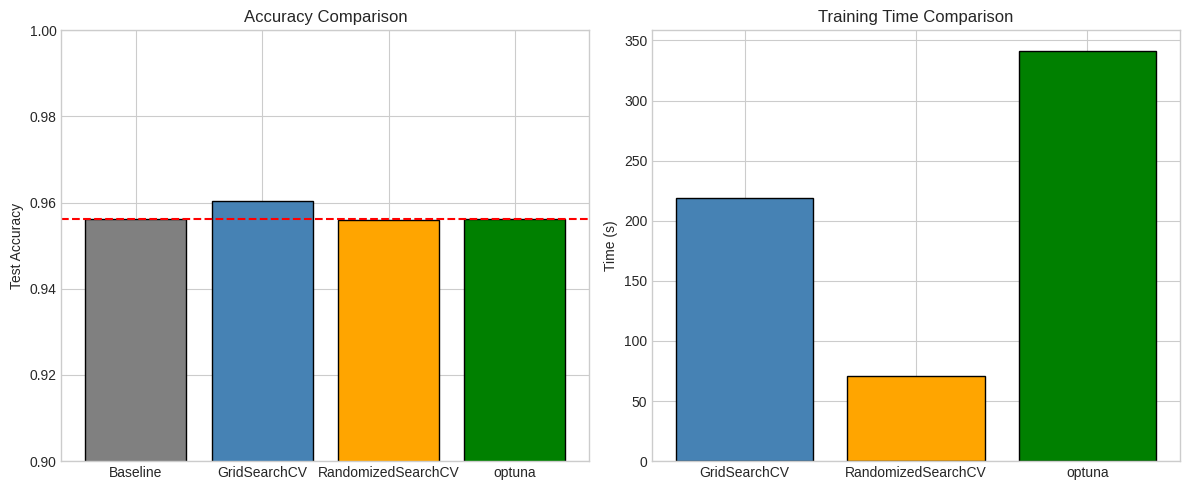

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['gray', 'steelblue', 'orange', 'green']

# Accuracy
axes[0].bar(comparison_df['Method'], comparison_df['Test Accuracy'], color=colors, edgecolor='black')
axes[0].axhline(y=baseline_score, color='red', linestyle='--', label='Baseline')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim(0.9, 1.0)

#Time
axes[1].bar(comparison_df['Method'][1:], comparison_df['Time (s)'][1:], color=colors[1:], edgecolor='black')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Training Time Comparison')

plt.tight_layout()
plt.show()

Training SVM with Optuna

In [41]:
def svm_objective(trial):
  params = {
      'C': trial.suggest_float('C', 0.01, 100, log=True),
      'gamma': trial.suggest_float('gamma', 0.001, 10, log=True),
      'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
  }

  if params['kernel'] == 'poly':
    params['degree'] = trial.suggest_int('degree', 2, 5)

  model = SVC(**params, random_state=42)
  scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')

  return scores.mean()

print("Tuning SVM . . .")
svm_study = optuna.create_study(direction='maximize')
svm_study.optimize(svm_objective, n_trials=30, show_progress_bar=True)

print(f"Best parameters: {svm_study.best_params}")
print(f"Best CV Score: {svm_study.best_value:.4f}")

#Test
best_svm = SVC(**svm_study.best_params, random_state=42)
best_svm.fit(x_train, y_train)
svm_test_score = best_svm.score(x_test, y_test)
print(f"Test score: {best_svm.score(x_test, y_test):.4f}")

Tuning SVM . . .


  0%|          | 0/30 [00:00<?, ?it/s]

Best parameters: {'C': 39.26779452189234, 'gamma': 0.007664208483482988, 'kernel': 'rbf'}
Best CV Score: 0.9780
Test score: 0.9737


Tuning Gradient Boosting

In [42]:
#Optuna for gradient boosting
def gb_objective(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 300),
      'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
      'max_depth': trial.suggest_int('max_depth', 2, 10),
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'random_state': 42

  }

  model = GradientBoostingClassifier(**params)
  scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')

  return scores.mean()

print("Tuning gradient boosting with Optuna. . . ")
gb_study = optuna.create_study(direction='maximize')
gb_study.optimize(gb_objective, n_trials=30, show_progress_bar=True)

print(f"Best parameters: {gb_study.best_params}")
print(f"Best CV Score: {gb_study.best_value}")

#Test
best_gb = GradientBoostingClassifier(**gb_study.best_params, random_state=42)
best_gb.fit(x_train, y_train)
gb_test_score = best_gb.score(x_test, y_test)
print(f"Test score: {gb_test_score:.4f}")

Tuning gradient boosting with Optuna. . . 


  0%|          | 0/30 [00:00<?, ?it/s]

Best parameters: {'n_estimators': 163, 'learning_rate': 0.17208144728560062, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 3, 'subsample': 0.6461434369730087}
Best CV Score: 0.9780219780219781
Test score: 0.9649


Nested Cross Validation

In [44]:
# Nested CV: Proper evaluation of tuned models
# Outer CV: Evaluate model
# Inner CV: Tune hyperparameters

print("Running Nested Cross-Validation...")
print("(This gives unbiased estimate of tuned model performance)")

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Simple param grid for speed
param_grid_nested = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

nested_scores = []

for i, (train_idx, test_idx) in enumerate(outer_cv.split(x_scaled, y)):
    X_outer_train, X_outer_test = x_scaled[train_idx], x_scaled[test_idx]
    y_outer_train, y_outer_test = y[train_idx], y[test_idx]

    # Inner CV for tuning
    inner_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid_nested,
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1
    )
    inner_search.fit(X_outer_train, y_outer_train)

    # Evaluate on outer test
    score = inner_search.score(X_outer_test, y_outer_test)
    nested_scores.append(score)
    print(f"  Fold {i+1}: {score:.4f} (Best params: {inner_search.best_params_})")

print(f"\nNested CV Score: {np.mean(nested_scores):.4f} ± {np.std(nested_scores):.4f}")

Running Nested Cross-Validation...
(This gives unbiased estimate of tuned model performance)
  Fold 1: 0.9649 (Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50})
  Fold 2: 0.9386 (Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100})
  Fold 3: 0.9474 (Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100})
  Fold 4: 0.9474 (Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50})
  Fold 5: 0.9735 (Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100})

Nested CV Score: 0.9543 ± 0.0128


## Summary

### Tuning Methods Comparison

| Method | Pros | Cons | Use When |
|--------|------|------|----------|
| GridSearchCV | Exhaustive, guaranteed | Slow, scales poorly | Small search space |
| RandomizedSearchCV | Faster, covers more | May miss optimal | Large search space |
| Optuna | Smart, efficient, pruning | More setup | Complex tuning |

### Key Takeaways

1. **Always tune** — defaults are rarely optimal
2. **Start with RandomSearch** — usually good enough
3. **Use Optuna** for serious tuning
4. **Nested CV** gives unbiased estimates
5. **Focus on important params** (check importance)

### Typical Improvement

- Tuning can improve accuracy by 1-5%
- Diminishing returns after initial tuning
- Data quality often matters more than tuning